# Modeling — Baseline Comparison

First-pass modeling with default parameters. Establishes performance floor (naive baselines) and ceiling (tree models with defaults) before hyperparameter tuning.

**Input:** `data/processed/ev_features.parquet`  
**Output:** `results/baseline_comparison.csv`, `results/best_baseline_model.pkl`

### Models
| # | Model | Type |
|---|-------|------|
| 1 | Persistence (lag 24h) | Naive baseline |
| 2 | Station hourly mean | Naive baseline |
| 3 | Ridge Regression | Linear |
| 4 | LightGBM (defaults) | Gradient boosting |
| 5 | XGBoost (defaults) | Gradient boosting |

### Train/Test Split
- **Train:** Jan 2021 – Jun 2022
- **Test:** Jul – Dec 2022

## 0. Setup & Load

In [ ]:
import warnings
import gc
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Find project root
current = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [current, *current.parents]:
    if (candidate / 'data' / 'raw').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing data/raw')

FEATURES_PATH  = PROJECT_ROOT / 'data' / 'processed' / 'ev_features.parquet'
RESULTS_DIR    = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')

In [3]:
df = pd.read_parquet(FEATURES_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')

# --- Train/test split ---
SPLIT_DATE = pd.Timestamp('2022-07-01')

train = df[df['timestamp_hour'] < SPLIT_DATE].copy()
test  = df[df['timestamp_hour'] >= SPLIT_DATE].copy()

print(f'Train: {len(train):,} rows  (up to {SPLIT_DATE.date()})')
print(f'Test:  {len(test):,} rows   (from {SPLIT_DATE.date()})')
print(f'Ratio: {len(train)/len(df)*100:.1f}% / {len(test)/len(df)*100:.1f}%')

# --- Define feature columns ---
EXCLUDE = ['customer_id', 'timestamp_hour', 'target', 'year']
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

X_train = train[FEATURE_COLS]
y_train = train['target']
X_test  = test[FEATURE_COLS]
y_test  = test['target']

print(f'\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}')

# Free memory
del df
gc.collect()

Loaded: 7,325,504 rows × 36 cols
Train: 4,804,041 rows  (up to 2022-07-01)
Test:  2,521,463 rows   (from 2022-07-01)
Ratio: 65.6% / 34.4%

Features (32): ['is_weekend', 'is_holiday', 'temperature_c', 'humidity_pct', 'precipitation_mm', 'wind_speed_kmh', 'cloud_cover_pct', 'is_raining', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_roll_mean_6h', 'load_roll_std_6h', 'load_roll_mean_12h', 'load_roll_std_12h', 'load_roll_mean_24h', 'load_roll_std_24h', 'load_roll_mean_7d', 'load_roll_std_7d', 'city_code', 'public_private_code', 'business_type_code', 'contract_type_code', 'contract_power_kw_norm', 'total_quantity_norm']


0

## 1. Evaluation Framework

In [4]:
results = []

def evaluate_model(name, y_true, y_pred):
    """Compute metrics and append to results list."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    # MAPE — exclude zeros to avoid division by zero
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    row = {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2}
    results.append(row)
    print(f'{name:<30} MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.1f}%  R²={r2:.4f}')
    return row


def plot_predictions(y_true, y_pred, title, n_points=500):
    """Scatter plot of actual vs predicted."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter — sample for readability
    idx = np.random.choice(len(y_true), min(n_points, len(y_true)), replace=False)
    axes[0].scatter(y_true.values[idx], y_pred[idx], s=5, alpha=0.3)
    lims = [0, max(y_true.values[idx].max(), y_pred[idx].max())]
    axes[0].plot(lims, lims, 'r--', linewidth=1)
    axes[0].set_xlabel('Actual (kWh)')
    axes[0].set_ylabel('Predicted (kWh)')
    axes[0].set_title(f'{title} — Actual vs Predicted')

    # Residual distribution
    residuals = y_true.values[idx] - y_pred[idx]
    axes[1].hist(residuals, bins=50, edgecolor='white', alpha=0.7)
    axes[1].set_xlabel('Residual (kWh)')
    axes[1].set_title(f'{title} — Residual Distribution')
    axes[1].axvline(0, color='red', linestyle='--')

    plt.tight_layout()
    plt.show()

print('Evaluation framework ready.')

Evaluation framework ready.


## 2. Naive Baselines

In [5]:
# --- Baseline 1: Persistence (predict = same hour yesterday) ---
y_pred_persist = test['load_lag_24h'].values
evaluate_model('Persistence (lag 24h)', y_test, y_pred_persist)

Persistence (lag 24h)          MAE=3.8054  RMSE=8.7587  MAPE=2164.6%  R²=0.3135


{'Model': 'Persistence (lag 24h)',
 'MAE': 3.8054402645122516,
 'RMSE': np.float64(8.75872230027282),
 'MAPE (%)': np.float64(2164.559519006638),
 'R²': 0.3134609125154275}

In [6]:
# --- Baseline 2: Station hourly mean ---
# Compute mean load per station per (hour_sin, hour_cos) from training data
# We use hour_sin and hour_cos to identify the hour (since raw hour was dropped)
train_means = train.groupby(
    ['customer_id', 'hour_sin', 'hour_cos']
)['target'].mean().rename('pred_station_mean')

test_with_mean = test.merge(
    train_means, on=['customer_id', 'hour_sin', 'hour_cos'], how='left'
)
# Fill any unmatched with global train mean
global_mean = y_train.mean()
y_pred_mean = test_with_mean['pred_station_mean'].fillna(global_mean).values

evaluate_model('Station Hourly Mean', y_test, y_pred_mean)

del train_means, test_with_mean
gc.collect()

Station Hourly Mean            MAE=3.2916  RMSE=6.8058  MAPE=1997.2%  R²=0.5855


7

## 3. Ridge Regression

Ridge Regression               MAE=2.5928  RMSE=5.3344  MAPE=1666.8%  R²=0.7453


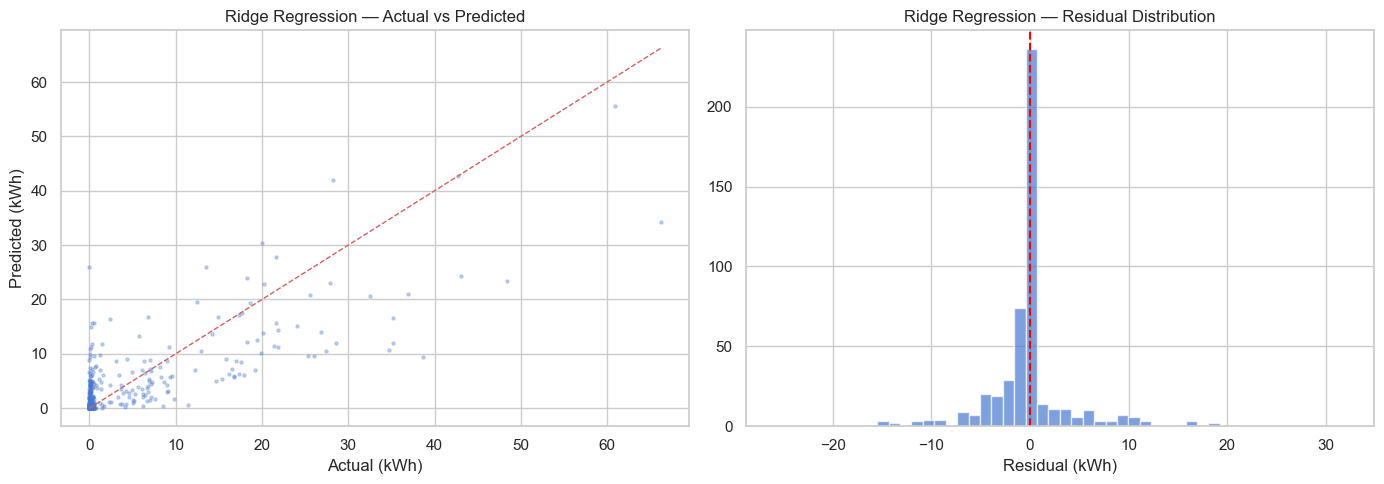

In [7]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)

# Clip negative predictions to 0 (load can't be negative)
y_pred_ridge = np.clip(y_pred_ridge, 0, None)

evaluate_model('Ridge Regression', y_test, y_pred_ridge)
plot_predictions(y_test, y_pred_ridge, 'Ridge Regression')

## 4. LightGBM (Default Parameters)

Best iteration: 500
LightGBM (default)             MAE=1.8642  RMSE=4.5578  MAPE=909.0%  R²=0.8141


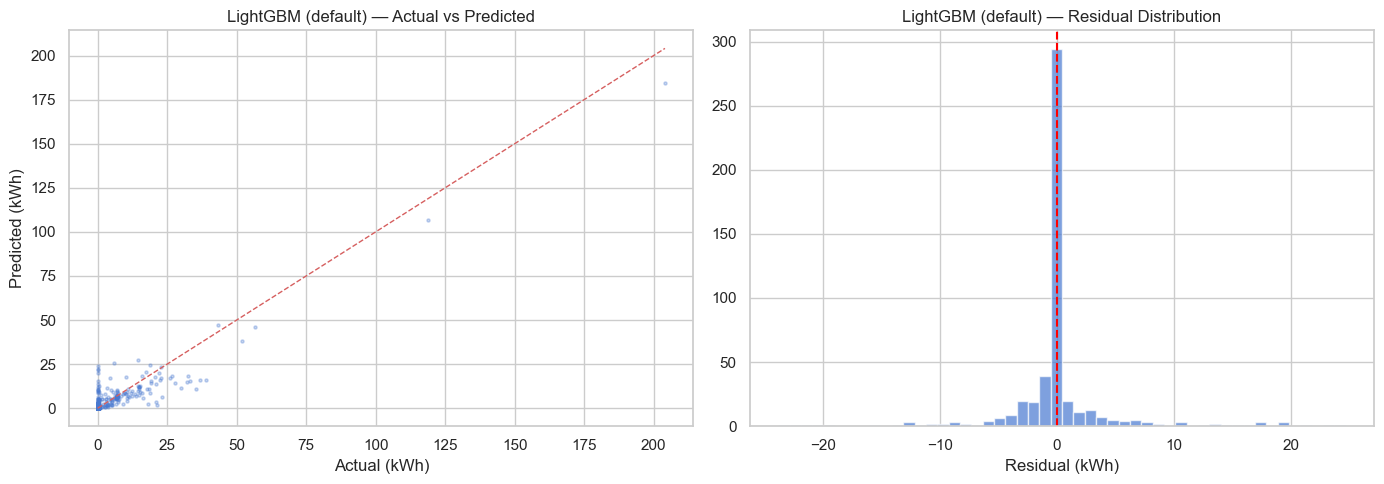

17770

In [8]:
# Use 10% of training data as validation for early stopping
split_idx = int(len(X_train) * 0.9)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

lgbm_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)

print(f'Best iteration: {lgbm_model.best_iteration_}')

y_pred_lgbm = lgbm_model.predict(X_test)
y_pred_lgbm = np.clip(y_pred_lgbm, 0, None)

evaluate_model('LightGBM (default)', y_test, y_pred_lgbm)
plot_predictions(y_test, y_pred_lgbm, 'LightGBM (default)')

del X_tr, X_val, y_tr, y_val
gc.collect()

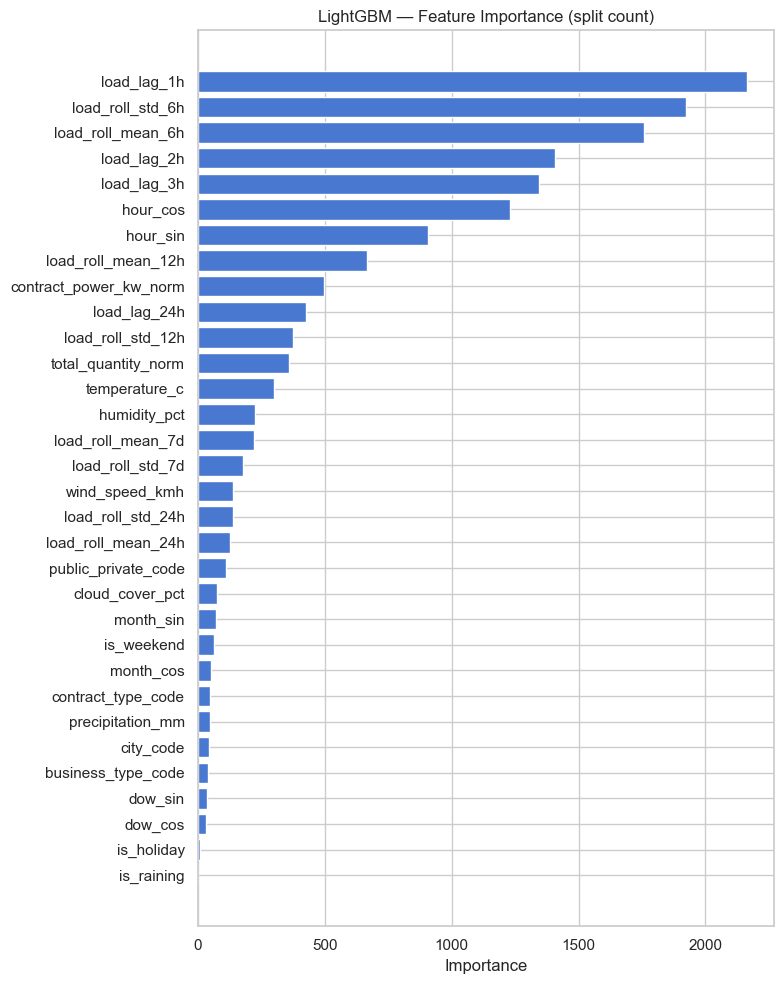

In [9]:
# Feature importance
importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(importance['feature'], importance['importance'])
ax.set_title('LightGBM — Feature Importance (split count)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 5. XGBoost (Default Parameters)

Best iteration: 499
XGBoost (default)              MAE=1.8387  RMSE=4.5233  MAPE=895.2%  R²=0.8169


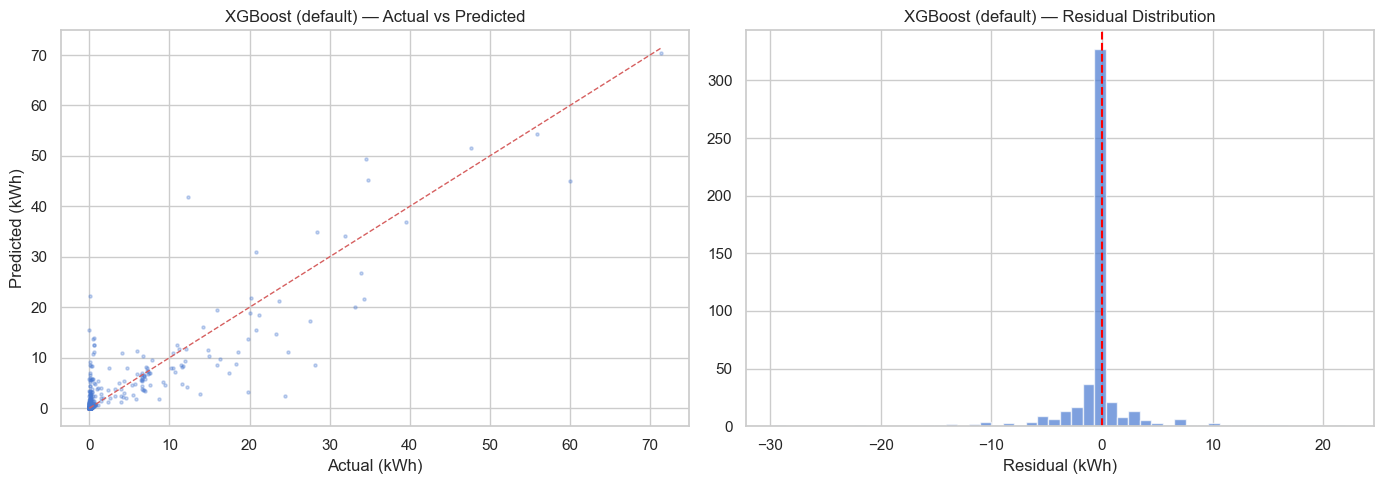

9097

In [11]:
# Use 10% of training data as validation for early stopping
split_idx = int(len(X_train) * 0.9)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    tree_method='hist',  # memory efficient
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f'Best iteration: {xgb_model.best_iteration}')

y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb = np.clip(y_pred_xgb, 0, None)

evaluate_model('XGBoost (default)', y_test, y_pred_xgb)
plot_predictions(y_test, y_pred_xgb, 'XGBoost (default)')

del X_tr, X_val, y_tr, y_val
gc.collect()

## 6. Model Comparison

                Model      MAE     RMSE    MAPE (%)       R²
Persistence (lag 24h) 3.805440 8.758722 2164.559519 0.313461
  Station Hourly Mean 3.291629 6.805806 1997.178287 0.585483
     Ridge Regression 2.592782 5.334432 1666.754970 0.745340
   LightGBM (default) 1.864229 4.557788  908.991321 0.814095
    XGBoost (default) 1.838715 4.523267  895.199277 0.816900


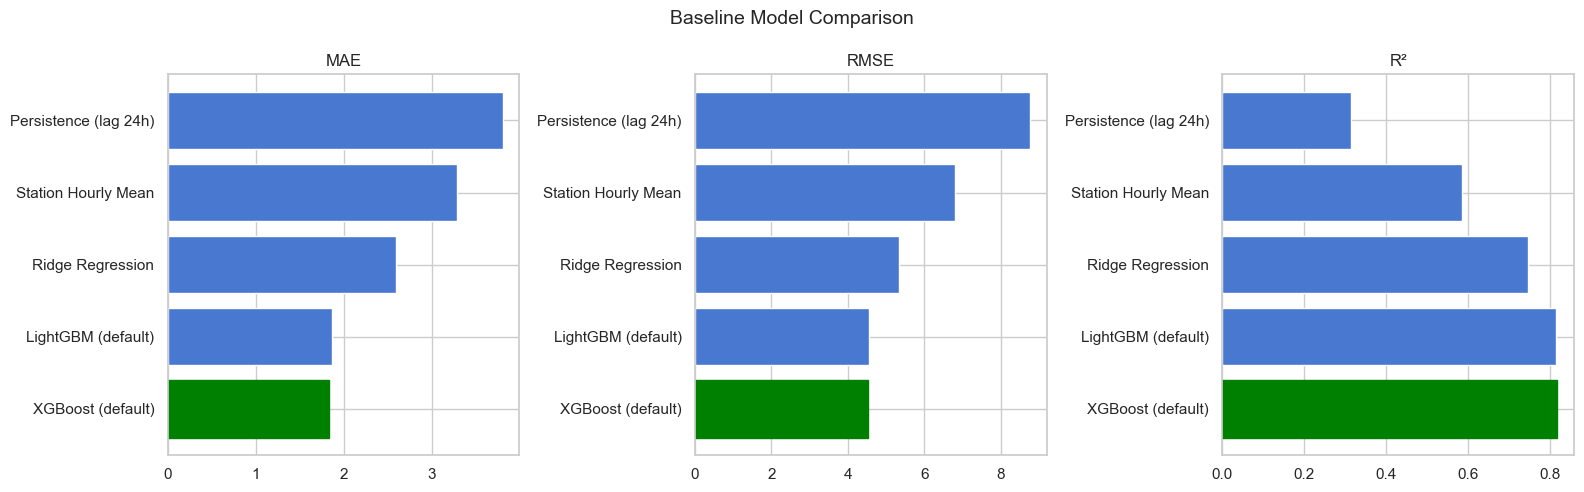

In [12]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# --- Bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    bars = axes[i].barh(results_df['Model'], results_df[metric])
    axes[i].set_title(metric)
    axes[i].invert_yaxis()

    # Color best value
    if metric == 'R²':
        best_idx = results_df[metric].idxmax()
    else:
        best_idx = results_df[metric].idxmin()
    bars[best_idx].set_color('green')

plt.suptitle('Baseline Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

Best model: XGBoost (default)


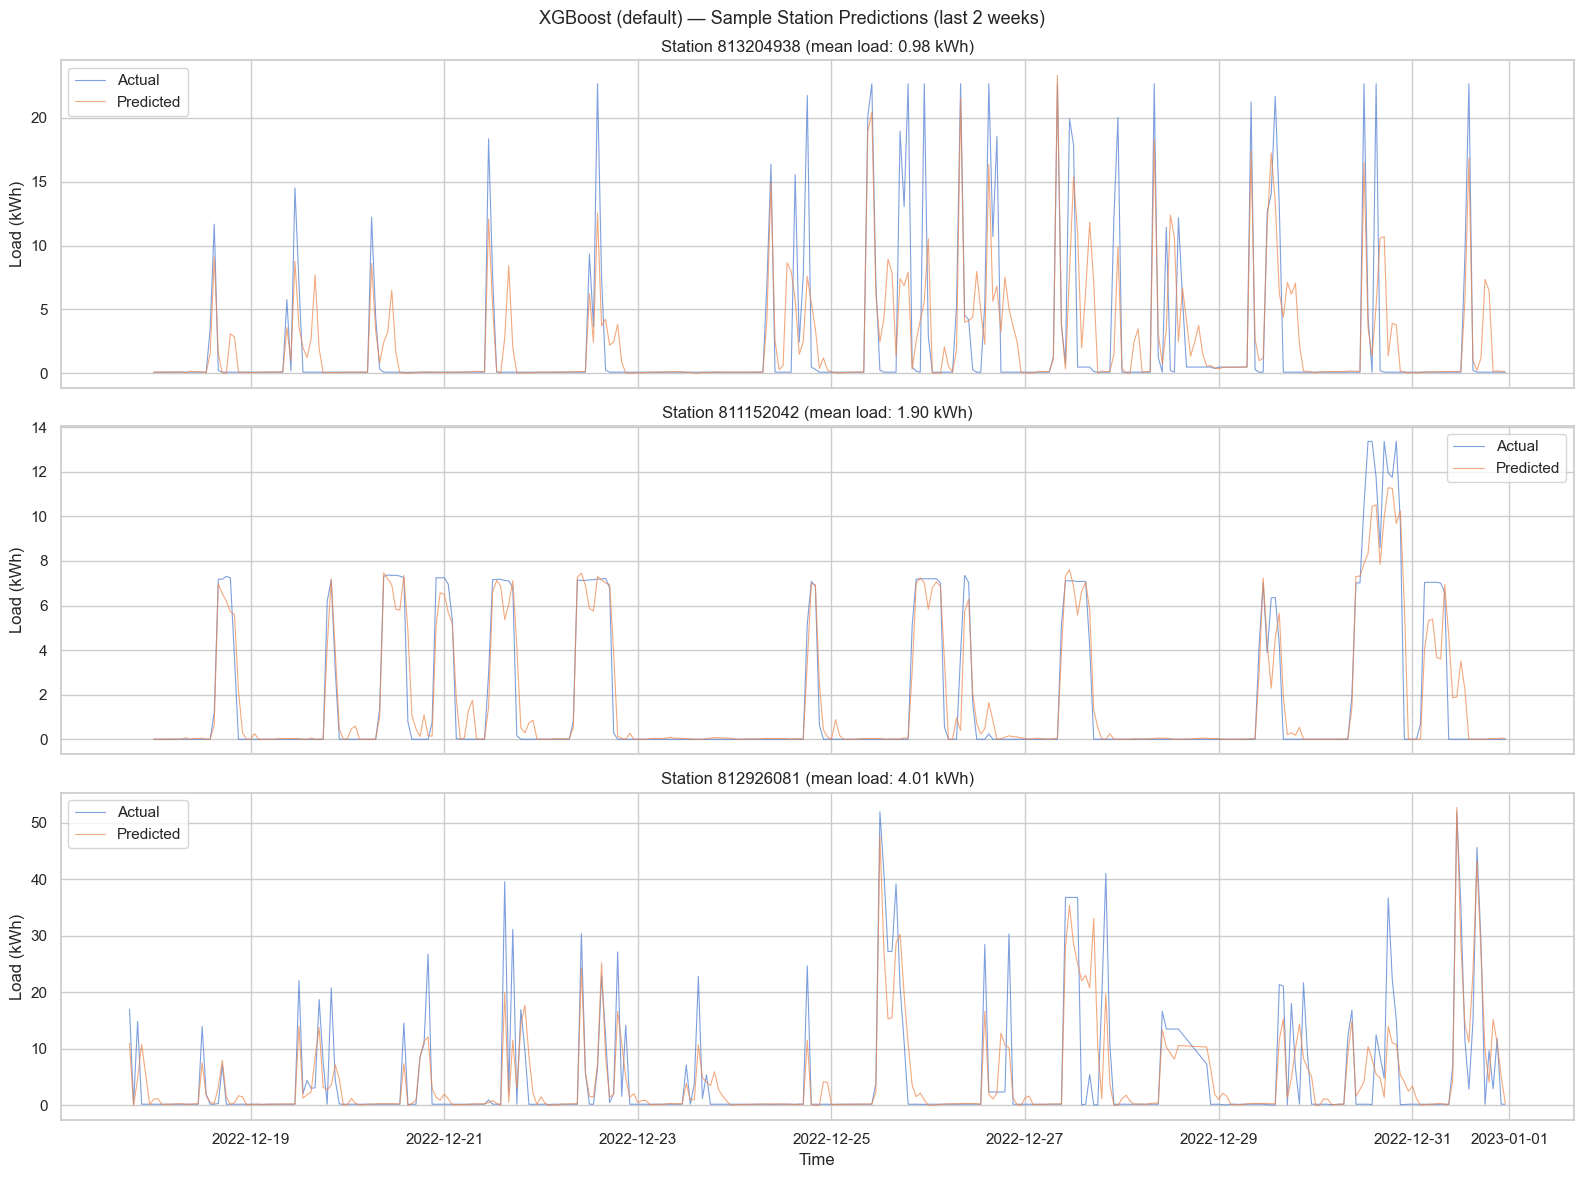

In [13]:
# --- Best model predictions on sample stations ---
# Find the best model (highest R²)
best_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f'Best model: {best_name}')

# Get corresponding predictions
pred_map = {
    'Persistence (lag 24h)': y_pred_persist,
    'Station Hourly Mean': y_pred_mean,
    'Ridge Regression': y_pred_ridge,
    'LightGBM (default)': y_pred_lgbm,
    'XGBoost (default)': y_pred_xgb,
}
best_preds = pred_map[best_name]

# Pick 3 sample stations with varying load levels
station_means = test.groupby('customer_id')['target'].mean().sort_values()
sample_stations = [
    station_means.index[len(station_means) // 4],       # low usage
    station_means.index[len(station_means) // 2],       # median usage
    station_means.index[3 * len(station_means) // 4],   # high usage
]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for i, station_id in enumerate(sample_stations):
    mask = test['customer_id'] == station_id
    ts = test.loc[mask, 'timestamp_hour'].values
    actual = test.loc[mask, 'target'].values
    predicted = best_preds[mask.values]

    # Show last 2 weeks for readability
    n_show = min(24 * 14, len(ts))
    axes[i].plot(ts[-n_show:], actual[-n_show:], alpha=0.7, label='Actual', linewidth=0.8)
    axes[i].plot(ts[-n_show:], predicted[-n_show:], alpha=0.7, label='Predicted', linewidth=0.8)
    axes[i].set_title(f'Station {station_id} (mean load: {actual.mean():.2f} kWh)')
    axes[i].set_ylabel('Load (kWh)')
    axes[i].legend()

axes[-1].set_xlabel('Time')
plt.suptitle(f'{best_name} — Sample Station Predictions (last 2 weeks)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Save Results

In [ ]:
# Save comparison table
results_df.to_csv(RESULTS_DIR / 'baseline_comparison.csv', index=False)
print(f'Saved comparison → {RESULTS_DIR / "baseline_comparison.csv"}')

# Save best model
best_model_map = {
    'Ridge Regression': ridge_pipe,
    'LightGBM (default)': lgbm_model,
    'XGBoost (default)': xgb_model,
}

if best_name in best_model_map:
    model_path = RESULTS_DIR / 'best_baseline_model.pkl'
    joblib.dump(best_model_map[best_name], model_path)
    print(f'Saved best model ({best_name}) → {model_path}')
else:
    print(f'Best model ({best_name}) is a naive baseline — no model object to save.')

print('\nDone. Proceed to 06 - Modeling (Tuned) for hyperparameter optimization.')